# Composite Basis Potential: Ibata et al. 2024 Example

This notebook is a **documentation + verification** page for the composite basis API in `tstrippy`.

For this first section, we verify density reconstruction quality as basis order increases:
1. Halo: Legendre order $\ell_{\max}$ (axisymmetric BFE).
2. Disks: Bessel/Hankel quadrature resolution $N_k$ (disk basis path).

No SciPy is used in this notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from astropy import units as u
from astropy import constants as const
import tstrippy
from tstrippy.lib import mathutils

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 12,
})

## Model Parameters (Table 2, $\beta_h=3$, $\mathcal{L}_{\max}^{\beta_h=3}$ column)

Using the attached Ibata et al. 2024 values:
- Halo: $\rho_{h,\odot}=11.4$ in units of $[M_\odot\,\mathrm{pc}^{-3}]/1000$, $q_h=0.735$, $\gamma_h=1.03$, $\beta_h=3$, $r_{0,h}=21.4\,\mathrm{kpc}$, and fixed $r_t=1000\,\mathrm{kpc}$.
- Thin disk: $M_d=3.34\times10^{10}M_\odot$, $h_{R,d}=2.241\,\mathrm{kpc}$, $h_{z,d}=0.348\,\mathrm{kpc}$.
- Thick disk: $M_t=0.84\times10^{10}M_\odot$, $h_{R,t}=1.74\,\mathrm{kpc}$, $h_{z,t}=0.858\,\mathrm{kpc}$.

In [2]:
# Gravitational constant in (km/s)^2 kpc / Msun
unitV = u.km / u.s
unitG = unitV**2 * (u.kpc / u.Msun)
G = const.G.to(unitG).value

# ---- Ibata-2024 halo parameters (beta fixed = 3, Lmax column) ----
rho_h_table = 11.4  # [Msun pc^-3]/1000
rho0_halo = (rho_h_table / 1000.0) * 1e9  # Msun / kpc^3
q_halo = 0.735
gamma_halo = 1.03
beta_halo = 3.0
r0_halo = 21.4
rt_halo = 1000.0

# ---- Disk parameters from same column ----
M_d = 3.34e10
M_t = 0.84e10
hR_d = 2.241
hZ_d = 0.348
hR_t = 1.74
hZ_t = 0.858

# For rho = Sigma0/(2 hz) exp(-R/hR - |z|/hz), total mass = 2 pi Sigma0 hR^2
Sigma0_d = M_d / (2.0 * np.pi * hR_d**2)
Sigma0_t = M_t / (2.0 * np.pi * hR_t**2)

def rho_ibata_halo(R, Z, rho0, r0, rt, q, gamma, beta):
    s = np.sqrt(R*R + (Z*Z)/(q*q))
    x = np.maximum(s / r0, 1e-14)
    return rho0 * x**(-gamma) * (1.0 + x)**(gamma - beta) * np.exp(-(s/rt)**2)

def rho_exp_disk(R, Z, Sigma0, hR, hZ):
    return (Sigma0 / (2.0 * hZ)) * np.exp(-R / hR - np.abs(Z) / hZ)

def rho_composite_analytic(R, Z):
    return (
        rho_ibata_halo(R, Z, rho0_halo, r0_halo, rt_halo, q_halo, gamma_halo, beta_halo)
        + rho_exp_disk(R, Z, Sigma0_d, hR_d, hZ_d)
        + rho_exp_disk(R, Z, Sigma0_t, hR_t, hZ_t)
    )

print(f'G = {G:.6e}')
print(f'rho0_halo = {rho0_halo:.3e} Msun/kpc^3')
print(f'Sigma0 thin = {Sigma0_d:.3e} Msun/kpc^2, Sigma0 thick = {Sigma0_t:.3e} Msun/kpc^2')

G = 4.300917e-06
rho0_halo = 1.140e+07 Msun/kpc^3
Sigma0 thin = 1.058e+09 Msun/kpc^2, Sigma0 thick = 4.416e+08 Msun/kpc^2


## Verification A: Halo Density Reconstruction vs $\ell_{\max}$

We project the Ibata halo onto Legendre modes on a radial grid, reconstruct $\rho(R,z)$, and compare to the analytic halo density.

This tests the **axisymmetric Legendre BFE** quality directly.

In [3]:
def gauss_legendre_numpy(n):
    mu, w = mathutils.gauss_legendre_nodes_weights(n)
    return np.array(mu, dtype=float), np.array(w, dtype=float)

In [4]:
def project_halo_legendre_coeffs(lmax, r_grid, n_mu=160):
    mu_q, w_q = gauss_legendre_numpy(n_mu)
    coeff = np.zeros((lmax + 1, r_grid.size), dtype=float)

    for i, r in enumerate(r_grid):
        s = r * np.sqrt(np.maximum(1.0 - mu_q*mu_q + (mu_q*mu_q)/(q_halo*q_halo), 0.0))
        x = np.maximum(s / r0_halo, 1e-14)
        rho_mu = rho0_halo * x**(-gamma_halo) * (1.0 + x)**(gamma_halo - beta_halo) * np.exp(-(s/rt_halo)**2)

        for ell in range(0, lmax + 1, 2):
            p_ell = np.array([mathutils.legendre_p_all_axisymmetric(ell, m)[-1] for m in mu_q], dtype=float)
            coeff[ell, i] = 0.5 * (2*ell + 1) * np.sum(w_q * rho_mu * p_ell)

    return coeff

In [5]:
def reconstruct_halo_density_map_from_coeffs(X, Z, r_grid, coeff):
    R = np.abs(X)
    r = np.sqrt(R*R + Z*Z)
    mu = np.zeros_like(r)
    nz = r > 0
    mu[nz] = Z[nz] / r[nz]

    r_clamp = np.clip(r, r_grid[0], r_grid[-1])
    lr = np.log(r_grid)
    lq = np.log(r_clamp)

    out = np.zeros_like(r)
    lmax = coeff.shape[0] - 1
    for ell in range(0, lmax + 1, 2):
        c_ell = np.interp(lq, lr, coeff[ell, :])
        p_ell = np.polynomial.legendre.Legendre.basis(ell)(mu)
        out += c_ell * p_ell

    return out

In [6]:
# Grid for X-Z density maps
xmax = 2*r0_halo
zmax = 2*r0_halo
nxy = 220
x = np.linspace(-xmax, xmax, nxy)
z = np.linspace(-zmax, zmax, nxy)
X, Z = np.meshgrid(x, z, indexing='xy')
R = np.abs(X)

In [7]:
# data to be plotted
rho_halo_true = rho_ibata_halo(R, Z, rho0_halo, r0_halo, rt_halo, q_halo, gamma_halo, beta_halo)

lmax_list = [3, 4, 8, 16, 24]
r_grid_halo = np.logspace(-2.5, 2.1, 140)

rho_halo_rec = []
halo_err = []
log_rho_rec = []#np.log10(np.clip(rho_b, eps_rho, None))
for lmax in lmax_list:
    coeff = project_halo_legendre_coeffs(lmax=lmax, r_grid=r_grid_halo, n_mu=160)
    rho_rec = reconstruct_halo_density_map_from_coeffs(X, Z, r_grid_halo, coeff)
    rho_halo_rec.append(rho_rec)
    rel = np.sqrt(np.mean((rho_rec - rho_halo_true)**2)) / np.sqrt(np.mean(rho_halo_true**2))
    halo_err.append(rel)
    log_rho_rec.append(np.log10(rho_halo_rec))


In [8]:
# properties of plot 
vmin = max(1e-12, 1e-4 * np.nanmax(rho_halo_true))
vmax = np.nanmax(rho_halo_true)
norm = mpl.colors.LogNorm(vmin=vmin, vmax=vmax)
vmax_rho = rho0_halo
vmin_rho = rho0_halo*1e-4
levels_rho = np.linspace(np.log10(rho_halo_true.min()), np.log10(rho_halo_true.max()), 8)

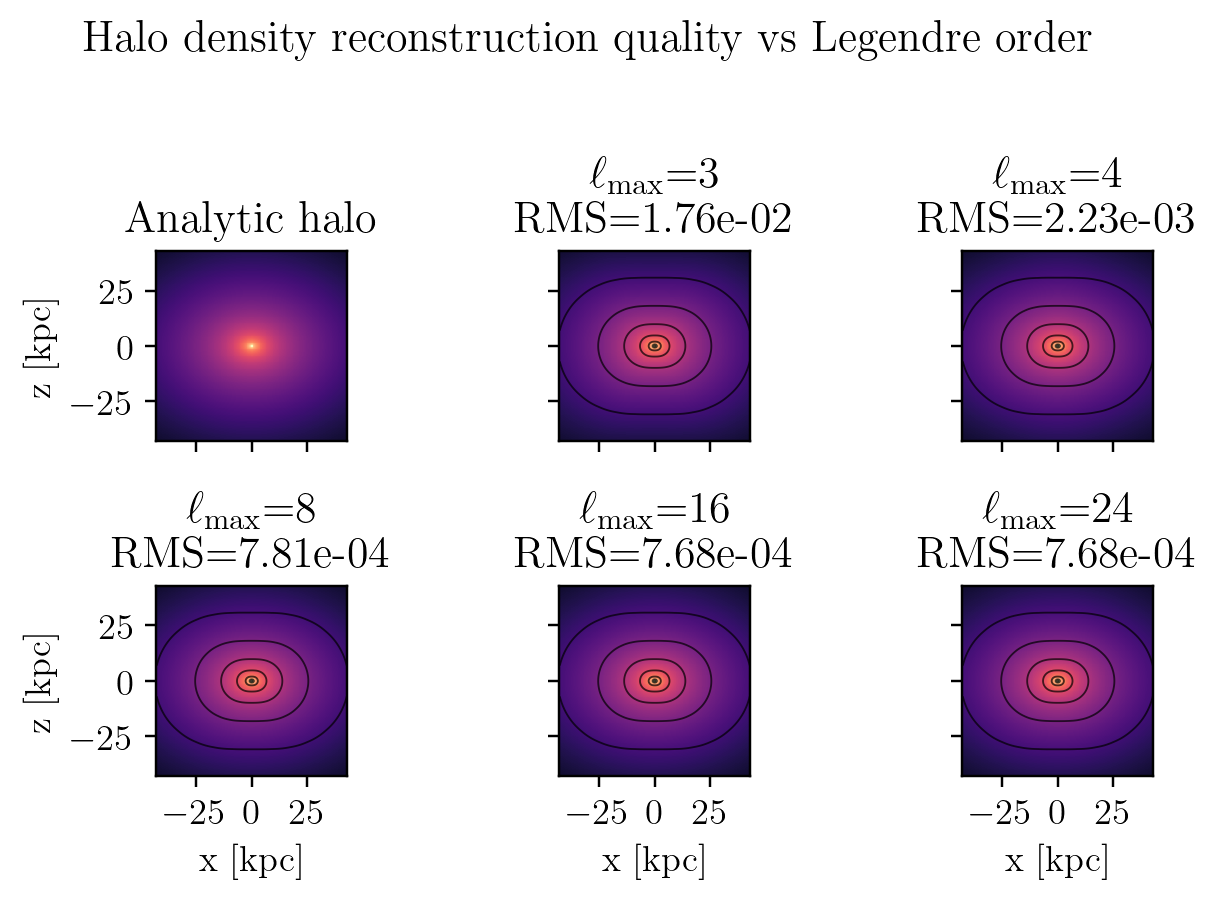

In [ ]:
nplots = len(lmax_list) + 1 
ncols = 3
nrow = nplots//ncols
if np.mod(nplots,ncols) > 0 :
    nrow = nplots//ncols + 1

fig, axes = plt.subplots(nrow,ncols, figsize=(8.25-2, 4), dpi=220, sharex=True, sharey=True)
# plot the analytical density profile 
im = axes[0][0].pcolormesh(X, Z, np.clip(rho_halo_true, vmin, None), shading='auto', cmap='magma', norm=norm)
axes[0][0].set_title('Analytic halo')
axes[0][0].set_ylabel('z [kpc]')
axes[0][0].set_aspect('equal')
# add the reconstructed plots 
for i in range(1,len(lmax_list)+1,1):
    plot_index = i 
    l_index = i - 1
    lmax = lmax_list[l_index]
    column = np.mod(plot_index,ncols)
    row = plot_index//ncols
    axes[row,column].pcolormesh(X, Z, np.clip(rho_halo_rec[l_index], vmin, None), shading='auto', cmap='magma', norm=norm)
    axes[row,column].set_title(r'$\ell_{\rm{max}}$='+"{:d}".format(lmax)+f'\nRMS={halo_err[l_index]:.2e}')
    axes[row,column].contour(X,Z,log_rho_rec[l_index][0], levels=levels_rho, colors="k", linewidths=0.6, alpha=0.7)
    axes[row,column].set_aspect('equal')
    if row==nrow-1:
        axes[row,column].set_xlabel('x [kpc]')
    if column==0:
        axes[row,column].set_ylabel('z [kpc]')


# cbar = fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.03, pad=0.01)
# cbar.set_label(r'$\rho_{\mathrm{halo}}$ [M$_\odot$ kpc$^{-3}$]')
fig.suptitle('Halo density reconstruction quality vs Legendre order', y=1.02)
plt.tight_layout()
plt.show()

## Verification B: Disk Density Reconstruction vs Bessel Resolution $N_k$

For exponential disks we use a Hankel/Bessel reconstruction of the radial exponential profile and test convergence with quadrature resolution.

This probes the **disk basis path** used for highly flattened components.

In [11]:
def radial_exp_from_bessel(Rabs, hR, nk=64, kmax_factor=40.0):
    # Reconstruct exp(-R/hR) via truncated Hankel integral
    kmax = kmax_factor / hR
    k = np.linspace(0.0, kmax, nk)
    dk = k[1] - k[0]

    # Analytic Hankel transform for exp(-R/hR):
    # exp(-R/hR) = int_0^inf k * J0(kR) * hR^2/(1 + (k hR)^2)^(3/2) dk
    Fk = hR*hR / (1.0 + (k*hR)**2)**1.5

    out = np.zeros_like(Rabs, dtype=float)
    for j in range(nk):
        w = 0.5 if (j == 0 or j == nk-1) else 1.0
        out += w * (k[j] * Fk[j]) * np.vectorize(mathutils.bessel_j0_scalar)(k[j] * Rabs)

    return out * dk

def rho_disk_from_bessel(Rabs, Z, Sigma0, hR, hZ, nk=64):
    radial = radial_exp_from_bessel(Rabs, hR, nk=nk)
    vertical = np.exp(-np.abs(Z)/hZ)
    return (Sigma0 / (2.0*hZ)) * radial * vertical

rho_disk_true = (
    rho_exp_disk(R, Z, Sigma0_d, hR_d, hZ_d)
    + rho_exp_disk(R, Z, Sigma0_t, hR_t, hZ_t)
)

In [30]:
# prepare data 
nk_list = [8, 16, 32, 64, 128]
rho_disk_rec = []
disk_err = []
for nk in nk_list:
    rho_rec = (
        rho_disk_from_bessel(R, Z, Sigma0_d, hR_d, hZ_d, nk=nk)
        + rho_disk_from_bessel(R, Z, Sigma0_t, hR_t, hZ_t, nk=nk)
    )
    rho_disk_rec.append(rho_rec)
    rel = np.sqrt(np.mean((rho_rec - rho_disk_true)**2)) / np.sqrt(np.mean(rho_disk_true**2))
    disk_err.append(rel)

vmin = max(1e-12, 1e-4 * np.nanmax(rho_disk_true))
vmax = 1e-1*np.nanmax(rho_disk_true)
norm = mpl.colors.LogNorm(vmin=vmin, vmax=vmax)
print(vmin,vmax)

97802.29137951543 97802291.37951544


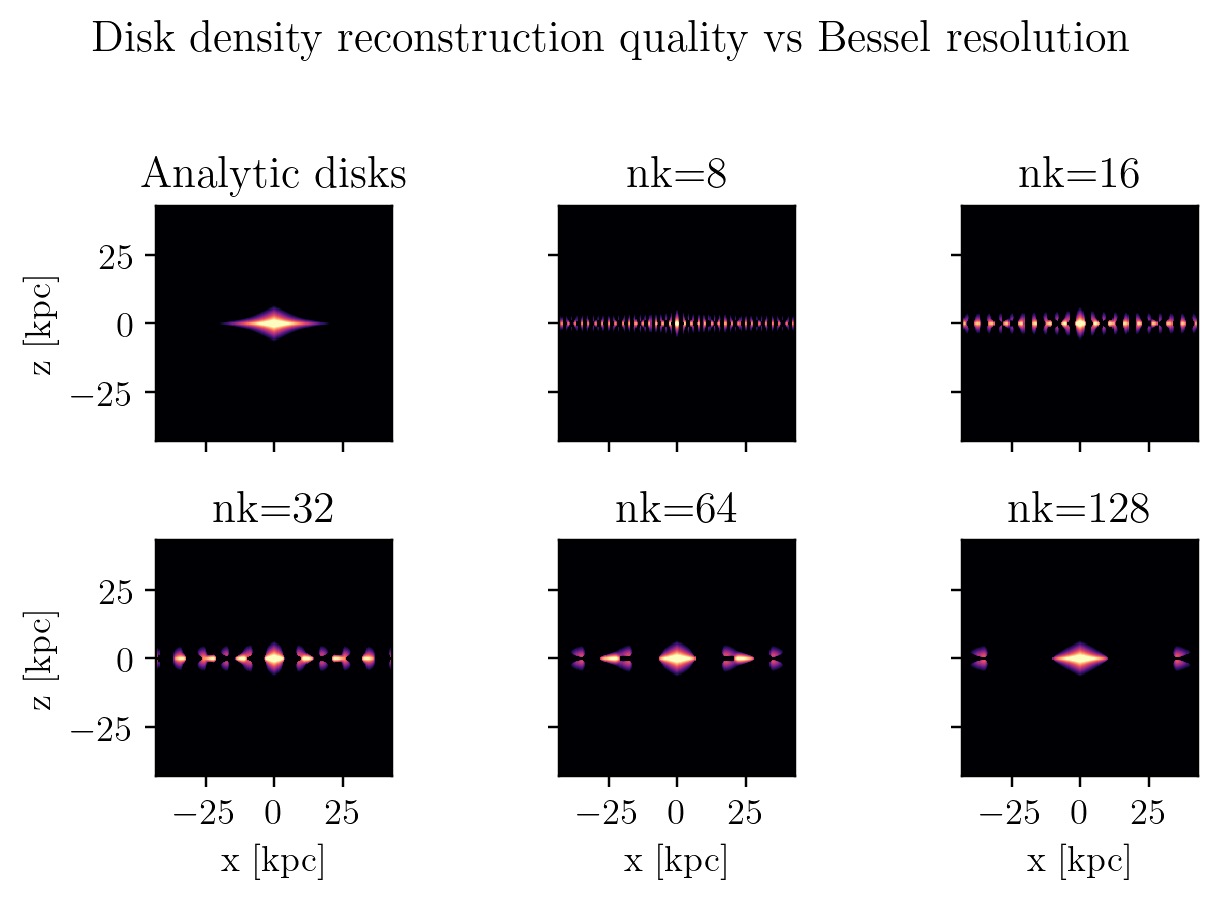

In [31]:
nplots = len(nk_list) + 1 
ncols = 3
nrow = nplots//ncols
if np.mod(nplots,ncols) > 0 :
    nrow = nplots//ncols + 1

fig, axes = plt.subplots(nrow, ncols, figsize=(8.25-2, 4), dpi=220, sharex=True, sharey=True)
im = axes[0,0].pcolormesh(X, Z, np.clip(rho_disk_true, vmin, None), shading='auto', cmap='magma', norm=norm)
axes[0,0].set_title('Analytic disks')
axes[0,0].set_ylabel('z [kpc]')
axes[0,0].set_aspect('equal')

# for i, nk in enumerate(1,nk_list+1):
for i in range(1,len(nk_list)+1):
    plot_index = i 
    nk_index = i - 1
    lmax = lmax_list[l_index]
    column = np.mod(plot_index,ncols)
    row = plot_index//ncols  
    axes[row,column].pcolormesh(X, Z, np.clip(rho_disk_rec[nk_index], vmin, None), shading='auto', cmap='magma', norm=norm)
    # axes[i+1].set_title(rf'$N_k={nk}$\nRMS={disk_err[i]:.2e}')
    axes[row,column].set_title(r'nk='+"{:d}".format(nk_list[nk_index]))
    axes[row,column].set_aspect('equal')
    if row==nrow-1:
        axes[row,column].set_xlabel('x [kpc]')
    if column==0:
        axes[row,column].set_ylabel('z [kpc]')


# cbar = fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.03, pad=0.01)
fig.suptitle('Disk density reconstruction quality vs Bessel resolution', y=1.02)
plt.tight_layout()
plt.show()

## Composite API Smoke Test (Three Components)

This final cell in Step 1 verifies that the composite basis API is callable for:
- component 1: Ibata halo (Legendre),
- component 2: thin disk (Bessel),
- component 3: thick disk (Bessel).

In [32]:
rgrid = np.logspace(-3, 2.2, 90)
lmax_demo = 24

tstrippy.integrator.clearcompositebasisexpansion()
tstrippy.integrator.initcompositebasisexpansion(G, lmax_demo, rgrid, 3)

tstrippy.integrator.addcompositeibata2024component(1, rho0_halo, r0_halo, rt_halo, q_halo, gamma_halo, beta_halo)
tstrippy.integrator.addcompositebesseldiskcomponent(2, Sigma0_d, hR_d, hZ_d)
tstrippy.integrator.addcompositebesseldiskcomponent(3, Sigma0_t, hR_t, hZ_t)
tstrippy.integrator.finalizecompositebasisexpansion()

# Minimal 1-particle integrator smoke test
kin = [[8.0], [0.0], [0.2], [0.0], [0.2], [0.0]]
tstrippy.integrator.deallocate()

# deallocate clears runtime state; re-set composite for this test path
tstrippy.integrator.clearcompositebasisexpansion()
tstrippy.integrator.initcompositebasisexpansion(G, lmax_demo, rgrid, 3)
tstrippy.integrator.addcompositeibata2024component(1, rho0_halo, r0_halo, rt_halo, q_halo, gamma_halo, beta_halo)
tstrippy.integrator.addcompositebesseldiskcomponent(2, Sigma0_d, hR_d, hZ_d)
tstrippy.integrator.addcompositebesseldiskcomponent(3, Sigma0_t, hR_t, hZ_t)
tstrippy.integrator.finalizecompositebasisexpansion()

tstrippy.integrator.setinitialkinematics(*kin)
tstrippy.integrator.setintegrationparameters(0.0, 1e-3, 2)
tstrippy.integrator.setstaticgalaxy('composite_basis', np.array([G]))
xt, yt, zt, vxt, vyt, vzt = tstrippy.integrator.leapfrogintime(2, 1)

print('Composite setup + integration smoke test: PASS')
print('Final position:', xt[0, -1], yt[0, -1], zt[0, -1])

Composite setup + integration smoke test: PASS
Final position: 8.00564025905022 0.00040010574248029236 0.2018837302264572


## Next Step

In the next section we will perform orbit-convergence tests for this same three-component model and compare trajectories across basis order.